**Outline - Data loading & quick preview**
- Import `pandas` and `numpy`.
- Load `processed_dataset.csv` from the data folder.
- Optional sampling via `SAMPLE_SIZE` for faster runs.
- Print dataset size and show the first rows.

In [1]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/processed_dataset.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

SAMPLE_SIZE = None 
if SAMPLE_SIZE is not None and len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
    print("Menggunakan sampel:", len(df))
else:
    print("Menggunakan semua data.")

print("Jumlah baris:", len(df))
print("Jumlah kolom:", df.shape[1])
display(df.head())

Menggunakan semua data.
Jumlah baris: 99994
Jumlah kolom: 80


,derived_msa_md,state_code,county_code,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,preapproval,lien_status,reverse_mortgage,loan_amount,...,loan_purpose_32,loan_purpose_4,loan_purpose_5,income_bracket_High,income_bracket_Low,income_bracket_Medium,income_bracket_Very High,loan_size_Large,loan_size_Medium,loan_size_Small
0,12580,md,24005.0,c,conventional:first lien,single family (1-4 units):site-built,2,1,2,465000,...,0,0,0,0,0,0,1,1,0,0
1,22220,ar,5007.0,c,conventional:first lien,single family (1-4 units):site-built,2,1,2,125000,...,0,0,0,0,0,0,1,0,0,1
2,43900,sc,45083.0,c,conventional:subordinate lien,single family (1-4 units):site-built,2,2,2,55000,...,0,1,0,0,0,0,0,0,0,1
3,19430,oh,39057.0,c,conventional:first lien,single family (1-4 units):site-built,2,1,2,65000,...,0,0,0,0,1,0,0,0,0,1
4,41700,tx,48029.0,c,conventional:first lien,single family (1-4 units):site-built,2,1,2,125000,...,0,0,0,0,0,0,0,0,0,1


**Outline - Item/feature preparation**
- Define helper to cap high-cardinality categories.
- Build binary columns from prefix rules and formatting to 0/1.
- Clean categorical columns (missing/sentinel values) and one-hot encode.
- Bin numeric columns with **domain-based boundaries** (industry-standard mortgage thresholds), clean invalid values (rate ≤ 0%, LTV > 120%), then one-hot encode. `income` & `loan_amount` are not re-binned — the phase-1 domain brackets (`income_bracket_*`, `loan_size_*`) already serve as binary items.
- Merge all items, drop structural/missing-only items, and sanity-check counts.

In [2]:
def cap_categories(series, top_n=10, other_label="other"):
    value_counts = series.value_counts(dropna=True)
    top = value_counts.nlargest(top_n).index
    return series.where(series.isin(top), other_label)

binary_prefixes = [
    "derived_sex_",
    "derived_race_",
    "derived_ethnicity_",
    "loan_type_",
    "loan_purpose_",
    "purchaser_type_",
]

binary_cols = [c for c in df.columns if any(c.startswith(p) for p in binary_prefixes)]
binary_df = df[binary_cols].copy()

binary_df = binary_df.apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)
binary_df = binary_df.clip(0, 1)

cat_cols = [
    "state_code",
    "conforming_loan_limit",
    "derived_loan_product_type",
    "derived_dwelling_category",
    "preapproval",
    "lien_status",
    "reverse_mortgage",
    "occupancy_type",
    "construction_method",
    "total_units",
    "applicant_age",
    "co_applicant_age",
    "applicant_age_above_62",
    "debt_to_income_ratio",
]
cat_cols = [c for c in cat_cols if c in df.columns]
cat_df = df[cat_cols].copy()

high_card_cols = {"state_code", "derived_loan_product_type", "derived_dwelling_category"}
sentinel_values = {"8888", "9999", "8888.0", "9999.0"}
sentinel_cols = ["applicant_age", "co_applicant_age"]
for col in cat_df.columns:
    cat_df[col] = cat_df[col].astype(str).str.strip().str.lower()
    cat_df[col] = cat_df[col].replace({"nan": "missing", "": "missing"})
    if col in sentinel_cols:
        cat_df[col] = cat_df[col].replace(sentinel_values, "missing")
    if col in high_card_cols:
        cat_df[col] = cap_categories(cat_df[col], top_n=10, other_label="other")

cat_ohe = pd.get_dummies(cat_df, prefix=cat_df.columns, dtype=int)

# --- Binning numerik BERBASIS DOMAIN (menggantikan qcut otomatis) ---
# qcut (equal-frequency) menghasilkan batas kuantil arbitrer yang tidak bisa
# diinterpretasikan (mis. income 71/127, LTV 82.976) dan gagal total pada
# loan_term: 74% data = 360 bulan sehingga satu bin berisi 72% observasi dan
# bin (1, 300] mencampur tenor 1 bulan dengan 25 tahun. Batas di bawah
# mengikuti konvensi industri KPR sehingga tiap item punya makna bisnis yang
# jelas dalam aturan asosiasi. Studi perbandingan teknik binning (qcut vs
# winsorize vs log) tetap dilakukan di sel analisis binning di bawah sebagai
# justifikasi metodologis.
# CATATAN: income & loan_amount sekarang di-bin dengan domain binning di bawah.
# Bracket fase 1 (income_bracket_*, loan_size_*) dihapus dari binary_prefixes
# untuk menghindari redundansi.

NUM_BIN_COLUMNS = [  # kolom numerik untuk studi perbandingan teknik binning
    "loan_amount",
    "income",
    "interest_rate",
    "combined_loan_to_value_ratio",
    "loan_term",
]

DOMAIN_BINS = {
    "loan_term": {
        # tenor KPR adalah variabel produk, bukan kontinu murni: 95% data ada di
        # nilai standar 120/180/240/300/360/480 bulan, dan 74% tepat 360 (30 thn)
        "edges": [0, 180, 300, 360, np.inf],
        "labels": [
            "max 15thn (pendek)",
            "15-25thn (menengah)",
            "30thn (KPR standar)",
            "di atas 30thn",
        ],
        "invalid": None,
    },
    "interest_rate": {
        # ambang mengikuti kisaran pasar KPR AS 2022; bunga <= 0% tidak masuk
        # akal untuk originasi baru sehingga dianggap error input
        "edges": [0, 3, 5, 7, np.inf],
        "labels": [
            "max 3% (rendah)",
            "3-5% (sedang)",
            "5-7% (tinggi)",
            "di atas 7% (sangat tinggi)",
        ],
        "invalid": lambda s: s <= 0,
    },
    "combined_loan_to_value_ratio": {
        # 80% = ambang uang muka konvensional (bebas PMI); 95-100% = program
        # DP minimal (FHA/VA/USDA); >100% = pinjaman melebihi nilai rumah;
        # >120% (max di data: 27.778%) = error input, di-set missing
        "edges": [0, 80, 95, 100, 120],
        "labels": [
            "max 80% (DP aman)",
            "80-95% (DP kecil)",
            "95-100% (DP minimal)",
            "100-120% (di atas nilai rumah)",
        ],
        "invalid": lambda s: (s <= 0) | (s > 120),
    },
    "income": {
        # Batas mengikuti klasifikasi Pew Research Center 2022 berdasarkan
        # US Census Bureau household data. Satuan HMDA = ribuan USD.
        # Lower < $56,600 | Middle $56,600-$169,800 | Upper > $169,800
        "edges": [0, 57, 170, np.inf],
        "labels": [
            "Lower-Income (max $56.6k)",
            "Middle-Income ($56.6k-$169.8k)",
            "Upper-Income (>$169.8k)",
        ],
        "invalid": lambda s: s <= 0,
    },
    "loan_amount": {
        # Batas Conforming mengikuti FHFA 2022 ($647,200 untuk 1-unit property).
        # 96.9% dataset = 1-unit. Rentang Conforming dipecah 3 via equal-depth
        # karena 93.8% data < $647.2k; batas dibulatkan ke $150k/$300k.
        # High-Balance + Jumbo digabung jadi Non-Conforming (6.2% data).
        "edges": [0, 150000, 300000, 647200, np.inf],
        "labels": [
            "Conforming-Kecil (max $150k)",
            "Conforming-Sedang ($150k-$300k)",
            "Conforming-Besar ($300k-$647.2k)",
            "Non-Conforming (>$647.2k)",
        ],
        "invalid": lambda s: s <= 0,
    },
}

bin_df = pd.DataFrame(index=df.index)
for col, spec in DOMAIN_BINS.items():
    if col not in df.columns:
        continue
    series = pd.to_numeric(df[col], errors="coerce")
    if spec["invalid"] is not None:
        invalid_mask = spec["invalid"](series)
        n_invalid = int(invalid_mask.sum())
        if n_invalid:
            series = series.mask(invalid_mask)
            print(f"'{col}': {n_invalid} nilai tidak valid di-set missing.")
    bin_df[f"{col}_bin"] = pd.cut(series, bins=spec["edges"], labels=spec["labels"])
    dist = bin_df[f"{col}_bin"].value_counts(normalize=True).sort_index()
    print(f"Distribusi {col}_bin:")
    for lbl, share in dist.items():
        print(f"  {str(lbl):<32s} {share*100:5.1f}%")

if not bin_df.empty:
    bin_df = bin_df.astype("string").fillna("missing").astype(str)
    bin_ohe = pd.get_dummies(bin_df, prefix=bin_df.columns, dtype=int)
else:
    bin_ohe = pd.DataFrame(index=df.index)


item_df = pd.concat([binary_df, cat_ohe, bin_ohe], axis=1)
item_df = item_df.loc[:, item_df.sum(axis=0) > 0]

# Buang item struktural/sentinel (missing, exempt, kode N/A). Co-occurrence item ini
# bersifat definisional/regulatif (mis. multifamily SELALU tanpa conforming limit),
# bukan pola perilaku, sehingga menghasilkan lift "palsu" yang mendominasi hasil dan
# membuat aturan jadi trivial. Membuangnya memaksa Apriori menemukan pola behavioral
# yang benar-benar non-obvious (sesuai Phase Goal).
structural_tokens = ("missing", "exempt", "_1111", "_8888", "_9999")
structural_cols = [c for c in item_df.columns if any(t in c.lower() for t in structural_tokens)]
if len(structural_cols) > 0:
    item_df = item_df.drop(columns=structural_cols)
    print("Item struktural/sentinel dihapus:", len(structural_cols))

if item_df.empty:
    raise ValueError("Itemset kosong. Cek kolom input atau kurangi filter.")

print("Jumlah item awal:", item_df.shape[1])

Distribusi loan_term_bin:
  max 15thn (pendek)                12.9%
  15-25thn (menengah)               10.3%
  30thn (KPR standar)               75.0%
  di atas 30thn                      1.8%
'interest_rate': 354 nilai tidak valid di-set missing.
Distribusi interest_rate_bin:
  max 3% (rendah)                   11.0%
  3-5% (sedang)                     48.6%
  5-7% (tinggi)                     33.9%
  di atas 7% (sangat tinggi)         6.5%
'combined_loan_to_value_ratio': 256 nilai tidak valid di-set missing.
Distribusi combined_loan_to_value_ratio_bin:
  max 80% (DP aman)                 65.2%
  80-95% (DP kecil)                 20.6%
  95-100% (DP minimal)              11.8%
  100-120% (di atas nilai rumah)     2.5%
'income': 704 nilai tidak valid di-set missing.
Distribusi income_bin:
  Lower-Income (max $56.6k)         21.6%
  Middle-Income ($56.6k-$169.8k)    58.5%
  Upper-Income (>$169.8k)           19.9%
Distribusi loan_amount_bin:
  Conforming-Kecil (max $150k)      32.1%
  C

Item struktural/sentinel dihapus: 8
Jumlah item awal: 135


In [3]:
import math

# Studi perbandingan STATISTIK jumlah/teknik bin (FD, Sturges, sqrt, CV) pada
# kelima kolom numerik. Hasilnya dipakai sebagai justifikasi di laporan;
# pipeline final memakai DOMAIN_BINS (lihat sel persiapan item di atas).

def _fd_bins(x):
    x = x.dropna()
    n = len(x)
    if n < 2:
        return None
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    if iqr <= 0:
        return None
    h = 2 * iqr * (n ** (-1 / 3))
    if h <= 0:
        return None
    bins = int(math.ceil((x.max() - x.min()) / h))
    return bins if bins > 0 else None

def _sturges_bins(n):
    return int(math.ceil(math.log2(n) + 1)) if n > 0 else None

def _sqrt_bins(n):
    return int(math.ceil(math.sqrt(n))) if n > 0 else None

def _evaluate_bins(x, bins, method="qcut"):
    if bins is None or bins < 2:
        return None
    try:
        if method == "qcut":
            binned = pd.qcut(x, q=bins, duplicates="drop")
        else:
            binned = pd.cut(x, bins=bins, duplicates="drop")
    except Exception:
        return None
    counts = binned.value_counts(dropna=True)
    if len(counts) == 0:
        return None
    min_count = int(counts.min())
    max_count = int(counts.max())
    mean_count = float(counts.mean())
    cv = float(counts.std(ddof=0) / mean_count) if mean_count > 0 else None
    empty_bins = int(bins - len(counts)) if method == "cut" else 0
    return {
        "method": method,
        "bins": int(bins),
        "min_count": min_count,
        "max_count": max_count,
        "cv": cv,
        "empty_bins": empty_bins,
    }

def _pick_best(results, n):
    if not results:
        return None
    df_res = pd.DataFrame(results).sort_values(
        by=["empty_bins", "cv", "bins"], ascending=[True, True, True]
    )
    min_ok = max(5, int(0.01 * n))
    df_res["min_ok"] = df_res["min_count"] >= min_ok
    best = df_res[df_res["min_ok"]].head(1)
    if best.empty:
        best = df_res.head(1)
    return best.iloc[0].to_dict()

def _outlier_share(x):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return float(((x < lower) | (x > upper)).mean())

summary_rows = []
detail_results = {}

for col in NUM_BIN_COLUMNS:
    if col not in df.columns:
        continue
    series = pd.to_numeric(df[col], errors="coerce").dropna()
    n = len(series)
    if n < 2:
        continue

    fd = _fd_bins(series)
    st = _sturges_bins(n)
    sq = _sqrt_bins(n)

    candidates = [3, 4, 5, fd, st, sq]
    candidates = sorted({c for c in candidates if c is not None and 2 <= c <= 10})

    results = []
    for c in candidates:
        res_q = _evaluate_bins(series, c, method="qcut")
        if res_q:
            results.append(res_q)
        res_c = _evaluate_bins(series, c, method="cut")
        if res_c:
            results.append(res_c)

    best = _pick_best(results, n)
    detail_results[col] = pd.DataFrame(results).sort_values(
        by=["empty_bins", "cv", "bins"], ascending=[True, True, True]
    )

    summary_rows.append(
        {
            "column": col,
            "n": n,
            "nunique": int(series.nunique()),
            "skew": float(series.skew()),
            "outlier_share": _outlier_share(series),
            "fd_bins": fd,
            "sturges_bins": st,
            "sqrt_bins": sq,
            "recommend_method": best["method"] if best else None,
            "recommend_bins": best["bins"] if best else None,
            "balance_cv": best["cv"] if best else None,
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values(by=["column"])
display(summary_df)

print("Detail evaluasi tersedia di: detail_results['nama_kolom']")

,column,n,nunique,skew,outlier_share,fd_bins,sturges_bins,sqrt_bins,recommend_method,recommend_bins,balance_cv
3,combined_loan_to_value_ratio,65489,21841,208.175694,0.019331,19079.0,17,256,qcut,3,0.000022
1,income,88816,1338,275.613520,0.071046,269508.0,18,299,qcut,3,0.006714
2,interest_rate,63507,1812,0.661481,0.023730,151.0,17,253,qcut,3,0.029991
0,loan_amount,99994,454,52.572100,0.047583,8653.0,18,317,qcut,4,0.026352
4,loan_term,96491,296,-1.846206,0.000000,NaN,18,311,qcut,5,0.921725


Detail evaluasi tersedia di: detail_results['nama_kolom']


In [4]:
import numpy as np

def _bin_summary(binned, requested_bins):
    counts = binned.value_counts(dropna=True)
    if len(counts) == 0:
        return None
    mean_count = float(counts.mean())
    cv = float(counts.std(ddof=0) / mean_count) if mean_count > 0 else None
    actual_bins = int(len(counts))
    empty_bins = int(requested_bins - actual_bins) if requested_bins and requested_bins > actual_bins else 0
    return {
        "min_count": int(counts.min()),
        "max_count": int(counts.max()),
        "cv": cv,
        "actual_bins": actual_bins,
        "empty_bins": empty_bins,
    }

def _bin_quantile(x, bins):
    binned = pd.qcut(x, q=bins, duplicates="drop")
    return _bin_summary(binned, bins)

def _bin_winsor_cut(x, bins, lower=0.01, upper=0.99):
    x_clip = x.clip(x.quantile(lower), x.quantile(upper))
    binned = pd.cut(x_clip, bins=bins, duplicates="drop")
    return _bin_summary(binned, bins)

def _bin_log_cut(x, bins):
    min_val = float(x.min())
    shift = 0.0
    if min_val <= -1:
        shift = -min_val + 1
    x_log = np.log1p(x + shift)
    binned = pd.cut(x_log, bins=bins, duplicates="drop")
    return _bin_summary(binned, bins)

def _get_bins_for_col(col):
    if "summary_df" in globals():
        match = summary_df[summary_df["column"] == col]
        if not match.empty and pd.notna(match["recommend_bins"].iloc[0]):
            return int(match["recommend_bins"].iloc[0])
    return 4

techniques = {
    "qcut": _bin_quantile,
    "winsor_cut": _bin_winsor_cut,
    "log_cut": _bin_log_cut,
}

rows = []
for col in NUM_BIN_COLUMNS:
    if col not in df.columns:
        continue
    series = pd.to_numeric(df[col], errors="coerce").dropna()
    if series.nunique() < 2:
        continue
    bins = _get_bins_for_col(col)
    bins = max(2, min(10, bins))
    for name, func in techniques.items():
        stats = func(series, bins)
        if stats is None:
            continue
        rows.append({
            "column": col,
            "technique": name,
            "bins": bins,
            **stats,
        })

compare_df = pd.DataFrame(rows).sort_values(
    by=["column", "empty_bins", "cv", "bins"], ascending=[True, True, True, True]
).reset_index(drop=True)
display(compare_df)

best_df = compare_df.groupby("column", as_index=False).head(1).reset_index(drop=True)
print("Rekomendasi terbaik per kolom (empty_bins -> cv -> bins):")
display(best_df)

,column,technique,bins,min_count,max_count,cv,actual_bins,empty_bins
0,combined_loan_to_value_ratio,qcut,3,21829,21830,0.000022,3,0
1,combined_loan_to_value_ratio,winsor_cut,3,6992,38601,0.594446,3,0
2,combined_loan_to_value_ratio,log_cut,3,8,61680,1.292780,3,0
3,income,qcut,3,29348,29832,0.006714,3,0
4,income,log_cut,3,14,48104,0.714113,3,0
5,income,winsor_cut,3,1963,80979,1.228216,3,0
6,interest_rate,qcut,3,20290,21767,0.029991,3,0
7,interest_rate,winsor_cut,3,5353,31777,0.538467,3,0
8,interest_rate,log_cut,3,599,42660,0.811738,3,0
9,loan_amount,qcut,4,24147,25867,0.026352,4,0


Rekomendasi terbaik per kolom (empty_bins -> cv -> bins):


,column,technique,bins,min_count,max_count,cv,actual_bins,empty_bins
0,combined_loan_to_value_ratio,qcut,3,21829,21830,0.000022,3,0
1,income,qcut,3,29348,29832,0.006714,3,0
2,interest_rate,qcut,3,20290,21767,0.029991,3,0
3,loan_amount,qcut,4,24147,25867,0.026352,4,0
4,loan_term,winsor_cut,5,1299,72747,1.392366,5,0


**Perbandingan Visual: 3 Teknik Binning untuk Data Outlier**

Data dalam dataset ini memiliki outlier signifikan (income skew≈276, loan_amount skew≈53).
Tiga teknik binning yang paling cocok untuk data beroutlier dievaluasi di sini:

| Teknik | Ide Utama | Keunggulan vs Outlier |
|--------|-----------|----------------------|
| **qcut** | Tiap bin = jumlah baris sama | Outlier masuk bin ujung, bin lain tetap penuh |
| **winsor_cut** | Potong ekstrem 1-99%, lalu equal-width | Outlier ekstrem dikompresi, tidak dibuang |
| **log_cut** | Log transform → skala kompres → equal-width | Jarak ekstrem mengecil secara visual |

Metric perbandingan: **CV (Coefficient of Variation)** antar bin — makin rendah = distribusi bin makin merata.

> **Catatan penting:** studi ini mengukur *keseimbangan statistik* antar bin, bukan *kebermaknaan batas bin*. qcut memang unggul secara CV, tetapi batas kuantilnya arbitrer (mis. income terbelah di 71/127 ribu USD) dan gagal pada `loan_term` yang 74% nilainya = 360 bulan. Karena itu **pipeline Apriori final memakai domain binning** (batas standar industri KPR) yang didefinisikan di sel persiapan item — studi di bawah menjadi justifikasi mengapa qcut ditolak meski menang CV.

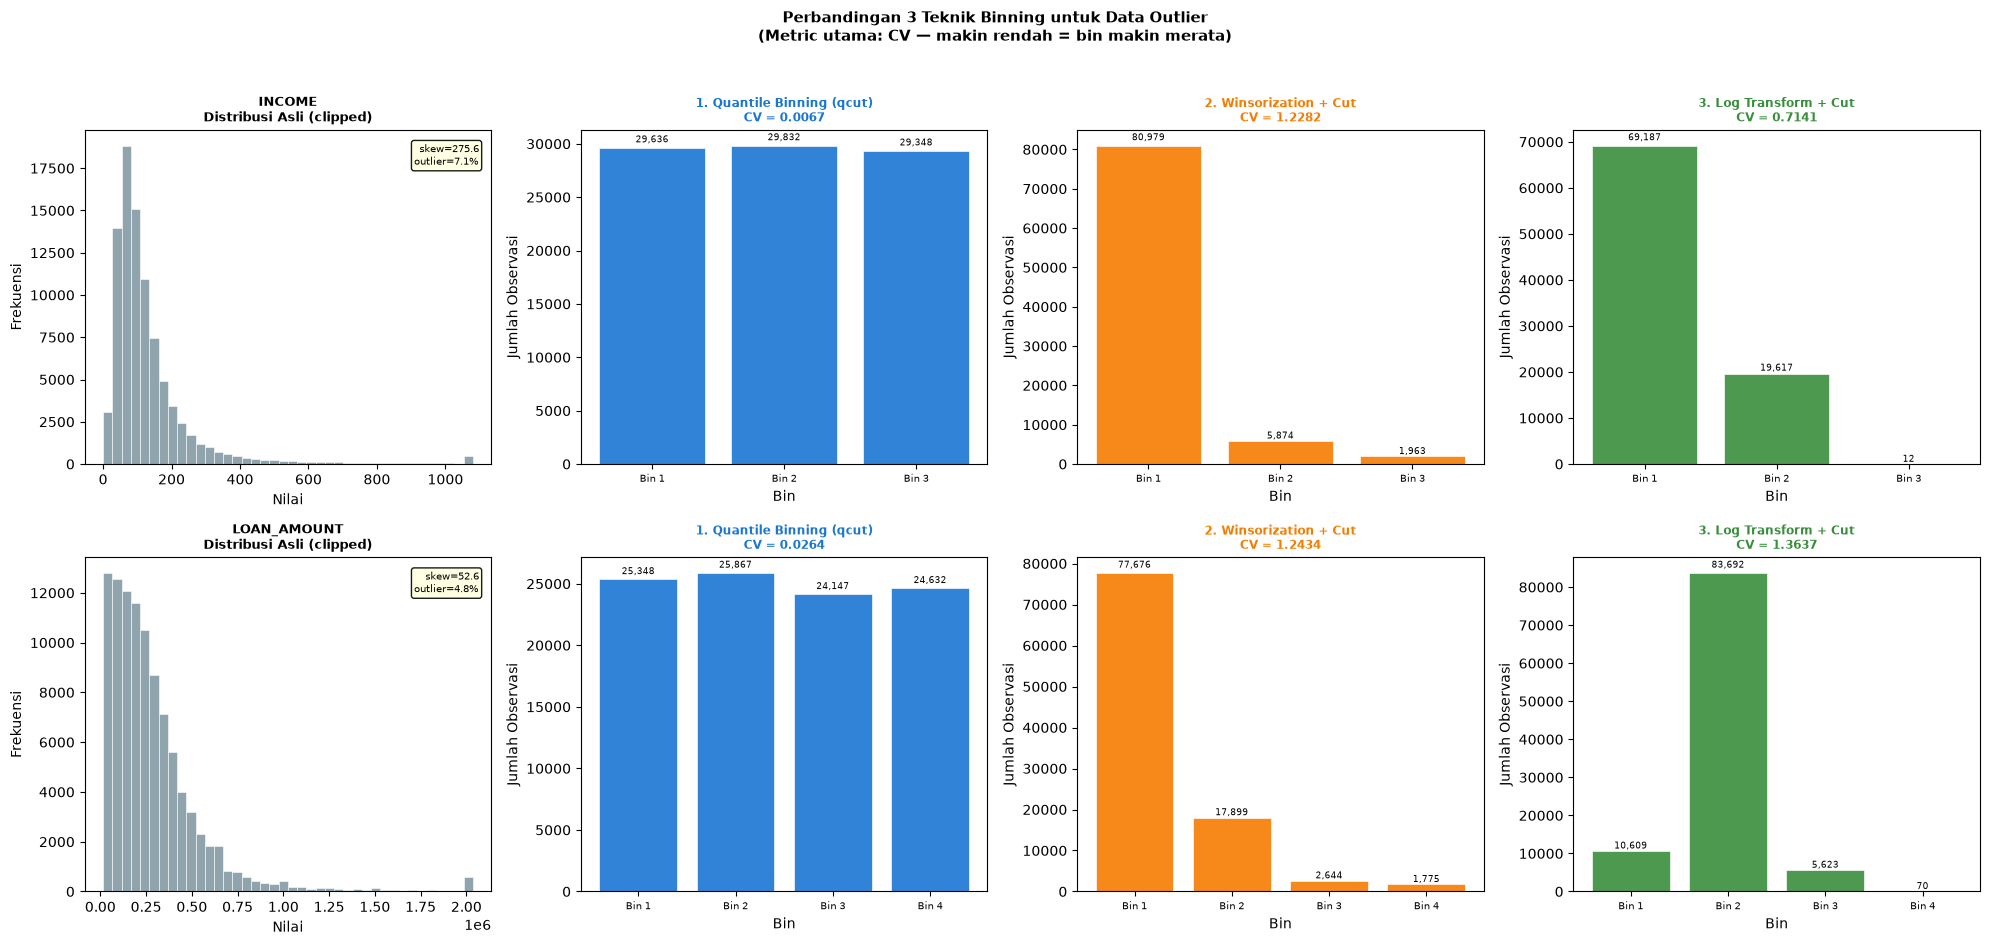

Gambar 1 disimpan: ../reports/3-binning_per_column.png


In [5]:

import matplotlib.pyplot as plt
import numpy as np

tech_colors_vis = {"qcut": "#1976D2", "winsor_cut": "#F57C00", "log_cut": "#388E3C"}
tech_pretty = {
    "qcut":       "1. Quantile Binning (qcut)",
    "winsor_cut": "2. Winsorization + Cut",
    "log_cut":    "3. Log Transform + Cut",
}

# ── Figure 1: Distribusi bin untuk income & loan_amount (kolom paling outlier) ──
show_cols = ["income", "loan_amount"]
fig1, axes = plt.subplots(len(show_cols), 4, figsize=(20, 4.8 * len(show_cols)))

for row_i, col in enumerate(show_cols):
    if col not in df.columns:
        continue
    series = pd.to_numeric(df[col], errors="coerce").dropna()
    bins_n = max(2, min(10, _get_bins_for_col(col)))
    outlier_pct = _outlier_share(series) * 100
    skew_val = float(series.skew())

    ax0 = axes[row_i, 0]
    ax0.hist(series.clip(series.quantile(0.005), series.quantile(0.995)),
             bins=40, color="#90A4AE", edgecolor="white", linewidth=0.4)
    ax0.set_title(f"{col.upper()}\nDistribusi Asli (clipped)", fontsize=9, fontweight="bold")
    ax0.set_xlabel("Nilai")
    ax0.set_ylabel("Frekuensi")
    ax0.text(0.97, 0.96, f"skew={skew_val:.1f}\noutlier={outlier_pct:.1f}%",
             transform=ax0.transAxes, ha="right", va="top", fontsize=7.5,
             bbox=dict(boxstyle="round,pad=0.25", fc="lightyellow", alpha=0.9))

    for col_i, tech in enumerate(["qcut", "winsor_cut", "log_cut"], start=1):
        ax = axes[row_i, col_i]
        try:
            if tech == "qcut":
                binned = pd.qcut(series, q=bins_n, duplicates="drop")
            elif tech == "winsor_cut":
                x2 = series.clip(series.quantile(0.01), series.quantile(0.99))
                binned = pd.cut(x2, bins=bins_n, duplicates="drop")
            else:
                shift = max(0.0, 1.0 - float(series.min()))
                x2 = np.log1p(series + shift)
                binned = pd.cut(x2, bins=bins_n, duplicates="drop")

            counts = binned.value_counts(dropna=True).sort_index()
            bars1 = ax.bar(range(len(counts)), counts.values,
                           color=tech_colors_vis[tech], edgecolor="white",
                           linewidth=0.5, alpha=0.9)
            for b_obj, cnt in zip(bars1, counts.values):
                ax.text(b_obj.get_x() + b_obj.get_width() / 2,
                        b_obj.get_height() * 1.01,
                        f"{cnt:,}", ha="center", va="bottom", fontsize=6.5)

            cv_row = compare_df[(compare_df["column"] == col) & (compare_df["technique"] == tech)]
            cv_str = f"CV = {float(cv_row['cv'].iloc[0]):.4f}" if len(cv_row) else ""
            ax.set_xticks(range(len(counts)))
            ax.set_xticklabels([f"Bin {j+1}" for j in range(len(counts))], fontsize=7.5)
            ax.set_title(f"{tech_pretty[tech]}\n{cv_str}", fontsize=8.5, fontweight="bold",
                         color=tech_colors_vis[tech])
            ax.set_xlabel("Bin")
            ax.set_ylabel("Jumlah Observasi")
        except Exception as e:
            ax.text(0.5, 0.5, str(e), transform=ax.transAxes, ha="center", fontsize=7)

fig1.suptitle(
    "Perbandingan 3 Teknik Binning untuk Data Outlier\n"
    "(Metric utama: CV — makin rendah = bin makin merata)",
    fontsize=11, fontweight="bold"
)
fig1.tight_layout(rect=[0, 0, 1, 0.96])
fig1.savefig("../reports/3-binning_per_column.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gambar 1 disimpan: ../reports/3-binning_per_column.png")


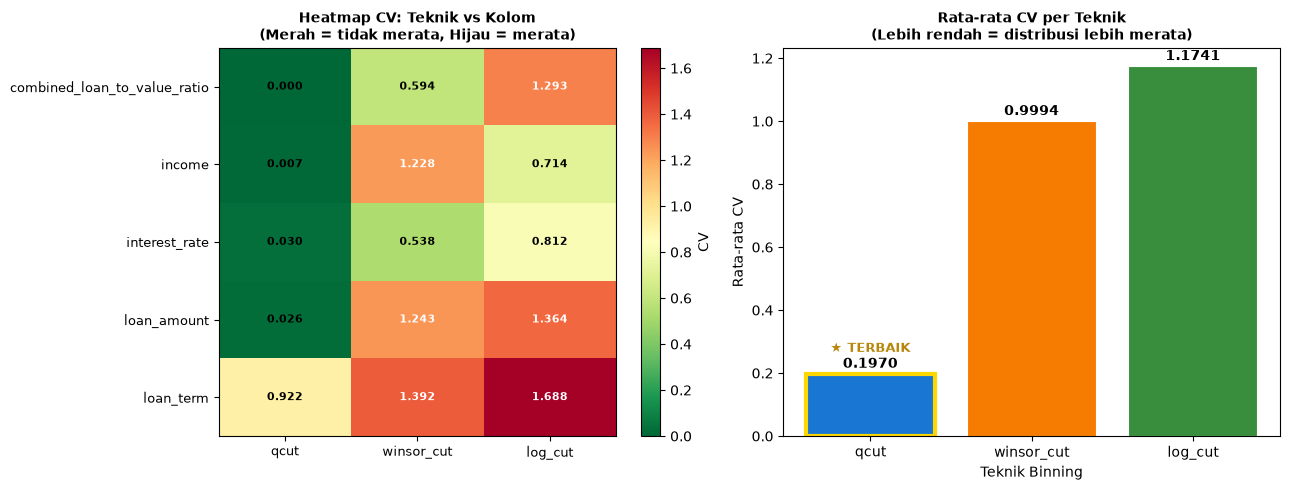

Gambar 2 disimpan: ../reports/3-binning_cv_comparison.png


In [6]:

# ── Figure 2: Heatmap CV + Rata-rata CV per Teknik ──
pivot_cv = compare_df.pivot_table(index="column", columns="technique", values="cv")
pivot_cv = pivot_cv.reindex(columns=["qcut", "winsor_cut", "log_cut"])

mean_cv_bar = compare_df.groupby("technique")["cv"].mean().reindex(["qcut", "winsor_cut", "log_cut"])
tech_colors_map = {"qcut": "#1976D2", "winsor_cut": "#F57C00", "log_cut": "#388E3C"}

fig2, (ax_heat, ax_bar) = plt.subplots(1, 2, figsize=(13, 5))

cmap = plt.get_cmap("RdYlGn_r")
vmax_val = float(compare_df["cv"].max())
im = ax_heat.imshow(pivot_cv.values, cmap=cmap, vmin=0, vmax=vmax_val, aspect="auto")
plt.colorbar(im, ax=ax_heat, label="CV")
ax_heat.set_xticks(range(len(pivot_cv.columns)))
ax_heat.set_xticklabels(pivot_cv.columns, fontsize=9)
ax_heat.set_yticks(range(len(pivot_cv.index)))
ax_heat.set_yticklabels(pivot_cv.index, fontsize=9)
ax_heat.set_title("Heatmap CV: Teknik vs Kolom\n(Merah = tidak merata, Hijau = merata)", fontsize=10, fontweight="bold")
for i in range(len(pivot_cv.index)):
    for j in range(len(pivot_cv.columns)):
        val = float(pivot_cv.values[i, j])
        if not np.isnan(val):
            text_color = "white" if val > vmax_val * 0.55 else "black"
            ax_heat.text(j, i, f"{val:.3f}", ha="center", va="center",
                        fontsize=8, fontweight="bold", color=text_color)

bar_col_list = [tech_colors_map.get(t, "#aaa") for t in mean_cv_bar.index]
bars2 = ax_bar.bar(mean_cv_bar.index, mean_cv_bar.values,
                   color=bar_col_list, edgecolor="white", linewidth=0.8)
ax_bar.set_title("Rata-rata CV per Teknik\n(Lebih rendah = distribusi lebih merata)", fontsize=10, fontweight="bold")
ax_bar.set_ylabel("Rata-rata CV")
ax_bar.set_xlabel("Teknik Binning")
for b, v in zip(bars2, mean_cv_bar.values):
    ax_bar.text(b.get_x() + b.get_width() / 2,
                b.get_height() + 0.008 * float(mean_cv_bar.max()),
                f"{v:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
winner_i = list(mean_cv_bar.index).index(mean_cv_bar.idxmin())
bars2[winner_i].set_edgecolor("#FFD700")
bars2[winner_i].set_linewidth(3)
ax_bar.text(winner_i,
            float(mean_cv_bar.iloc[winner_i]) + float(mean_cv_bar.max()) * 0.06,
            "★ TERBAIK", ha="center", fontsize=9, color="#B8860B", fontweight="bold")

fig2.tight_layout()
fig2.savefig("../reports/3-binning_cv_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gambar 2 disimpan: ../reports/3-binning_cv_comparison.png")


## 4. Apriori & Rule Filtering (Penentuan Threshold & Anti-Tautology)

### Justifikasi Pemilihan Threshold (Alasan Min-Support & Min-Confidence):
1. **Min-Support = 0.001 (0.1%)**:
   - *Alasan Statistik & Bisnis*: Dataset HMDA setelah preprocessing sangat masif (~100.000+ baris). Jika menggunakan batas konvensional seperti 1% atau 5%, kita membutuhkan 1.000 hingga 5.000 transaksi berulang untuk satu pola. Akibatnya, kita akan kehilangan pola-pola pada segmen khusus/minoritas (seperti *second mortgage*, rumah *manufactured*, atau pinjaman VA/jumbo) yang porsinya di bawah 1% dari total populasi, namun membawa eksposur risiko dan implikasi strategi bisnis yang sangat besar.
2. **Min-Confidence = 0.6 (60%)**:
   - *Alasan Statistik & Bisnis*: Dalam manajemen risiko kredit dan penawaran produk KPR, bank membutuhkan kepastian prediktif yang mayoritas. Batas 60% (di mana top rules kita mencapai 70% hingga 100%) menjamin bahwa aturan yang ditemukan adalah ketetapan perilaku yang dapat diandalkan untuk kebijakan underwriting atau marketing, bukan sebaran acak.
3. **Min-Lift >= 1.5 - 2.0**:
   - *Alasan Statistik & Bisnis*: Lift mengukur seberapa kuat hubungan antar item dibandingkan jika kedua item tersebut muncul secara independen. Dengan menetapkan Lift $\ge 2.0$, kita menyingkirkan pola-pola yang muncul hanya karena produk tersebut dominan di pasar (seperti KPR 30 tahun konvensional). Ini memastikan analisis berfokus eksklusif pada "Non-Obvious Relationships" -- hubungan tersembunyi yang bernilai tinggi bagi pengambil keputusan bank.

### Langkah Eksekusi:
- Import `mlxtend` dan terapkan threshold (`MIN_SUPPORT`, `MIN_CONF`, `MIN_LIFT`).
- Definisikan `CORRELATED_GROUPS` untuk menyaring dan membuang aturan tautologi (misal aturan definisi usia atau konstruksi).
- Jalankan algoritma Apriori dan Association Rules.

In [7]:
try:
    from mlxtend.frequent_patterns import apriori, association_rules
except ImportError as exc:
    raise ImportError("Paket mlxtend belum terpasang. Instal dulu: pip install mlxtend") from exc

MIN_SUPPORT = 0.001 
MIN_CONF = 0.6
MIN_LIFT = 1.5
MAX_ITEMSETS = 150 
MAX_LEN = 3

CORRELATED_GROUPS = [
    {"loan_type_", "derived_loan_product_type_"},
    {"lien_status_", "derived_loan_product_type_"},
    {"applicant_age_", "applicant_age_above_62_"},
    {"co_applicant_age_", "applicant_age_"},
    # usia applicant & co-applicant sangat berkorelasi (pasangan seumuran),
    # jadi co_applicant_age <-> above_62 sama tautologisnya dengan
    # co_applicant_age <-> applicant_age di atas.
    {"co_applicant_age_", "applicant_age_above_62_"},
    {"conforming_loan_limit_", "loan_amount_bin_"},
    {"preapproval_", "loan_purpose_"},
    # derived_dwelling_category adalah TURUNAN dari construction_method + total_units,
    # jadi aturan yang menautkan keduanya bersifat definisional (tautologi), bukan temuan.
    {"derived_dwelling_category_", "construction_method_"},
    {"derived_dwelling_category_", "total_units_"},
    # reverse mortgage (HECM) mensyaratkan usia 62+ secara regulasi,
    # jadi keterkaitannya dengan above_62 adalah fakta hukum, bukan temuan.
    {"reverse_mortgage_", "applicant_age_above_62_"},
]

# Tiap item diatribusikan ke SATU prefix atribut (yang terpanjang). Tanpa ini,
# "applicant_age_above_62_yes" match dua prefix sekaligus dalam grup
# {applicant_age_, applicant_age_above_62_} sehingga rule APAPUN yang memuat
# item itu -- bahkan berpasangan dengan atribut lain -- ikut tercap tautologi.
ALL_GROUP_PREFIXES = sorted({p for g in CORRELATED_GROUPS for p in g}, key=len, reverse=True)

def item_attribute(item):
    text = str(item)
    for p in ALL_GROUP_PREFIXES:
        if text.startswith(p):
            return p
    return None

def is_tautological(row):
    items = set(row["antecedents"]).union(row["consequents"])
    attrs = {item_attribute(i) for i in items}
    attrs.discard(None)
    for group in CORRELATED_GROUPS:
        if len(attrs & group) >= 2:
            return True
    return False

def apply_filters(rules_df, min_lift):
    rules_df = rules_df[rules_df["lift"] >= min_lift]
    rules_df = rules_df[rules_df["consequents"].apply(lambda x: len(x) == 1)]
    tautology_mask = rules_df.apply(is_tautological, axis=1)
    tautology_count = int(tautology_mask.sum())
    rules_df = rules_df[~tautology_mask]
    return rules_df, tautology_count

item_support = item_df.mean(axis=0)
item_df_filtered = item_df.loc[:, item_support >= MIN_SUPPORT]

if item_df_filtered.shape[1] == 0:
    raise ValueError("Tidak ada item dengan support >= MIN_SUPPORT. Turunkan MIN_SUPPORT.")

# Batasi jumlah item agar Apriori tidak memakan memori berlebihan
if item_df_filtered.shape[1] > MAX_ITEMSETS:
    top_items = item_support.sort_values(ascending=False).head(MAX_ITEMSETS).index
    item_df_filtered = item_df_filtered[top_items]
    print("Item dibatasi ke:", len(top_items))

item_df_filtered = item_df_filtered.astype(bool)

print("Jumlah item setelah filter support:", item_df_filtered.shape[1])

frequent_itemsets = apriori(
    item_df_filtered,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=MAX_LEN,
    low_memory=True,
 )
print("Frequent itemsets:", len(frequent_itemsets))

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=MIN_CONF)
rules, tautology_removed = apply_filters(rules, MIN_LIFT)

if len(rules) < 10:
    relax_confs = [0.55, 0.5, 0.45]
    for conf in relax_confs:
        rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=conf)
        rules, tautology_removed = apply_filters(rules, MIN_LIFT)
        if len(rules) >= 10:
            MIN_CONF = conf
            break

print("Jumlah rules setelah filter:", len(rules))
print("Rules terhapus (tautologi):", tautology_removed)
print("Threshold akhir -> support:", MIN_SUPPORT, "confidence:", MIN_CONF, "lift:", MIN_LIFT)

Jumlah item setelah filter support: 124


Frequent itemsets: 88680


Jumlah rules setelah filter: 4016
Rules terhapus (tautologi): 1697
Threshold akhir -> support: 0.001 confidence: 0.6 lift: 1.5


**Outline - Reporting & export**
- Normalize/clean item names for consistent grouping.
- Select diverse top rules with group caps and lift threshold.
- Build display tables for the report and show top 10.
- Save full rules to CSV and a text summary to reports.

In [8]:
def format_itemset(itemset):
    return ", ".join(sorted([str(x) for x in itemset]))
# 2. Binning teknik yang cocok untuk data outlier

def parse_itemset_str(text):
    if not isinstance(text, str) or text.strip() == "":
        return []
    return [t.strip() for t in text.split(",")]

MINOR_PREFIXES = ("total_units_", "occupancy_type_", "derived_race_")

def canonical_item(item):
    text = str(item).strip().lower()
    if text == "lien_status_2":
        return "subordinate_lien"
    if "subordinate lien" in text:
        return "subordinate_lien"
    # Kolapskan bucket ordinal supaya rule yang hanya beda bin/rentang (mis. DTI 38 vs 39,
    # atau bin LTV bersebelahan) dianggap pola SAMA dan tidak tampil dobel di top-10.
    if text.startswith("debt_to_income_ratio_"):
        return "debt_to_income_ratio"
    if "_bin_" in text:
        return text.split("_bin_")[0] + "_bin"
    return text

def canonicalize_items(items):
    return [canonical_item(i) for i in items]

def core_antecedent_key(items):
    canon = canonicalize_items(items)
    core = [i for i in canon if not i.startswith(MINOR_PREFIXES)]
    return tuple(sorted(core))

def rule_signature(antecedent_items, consequent_items):
    ant_key = core_antecedent_key(antecedent_items)
    cons_key = tuple(sorted(canonicalize_items(consequent_items)))
    return (ant_key, cons_key)

CONSEQUENT_GROUPS = [
    {"name": "loan_product", "prefixes": {"loan_type_", "derived_loan_product_type_", "lien_status_"}},
    {"name": "income_group", "prefixes": {"income_bracket_", "income_bin_"}},
    {"name": "loan_size_group", "prefixes": {"loan_size_", "loan_amount_bin_", "conforming_loan_limit_"}},
    {"name": "preapproval_purpose", "prefixes": {"preapproval_", "loan_purpose_"}},
    {"name": "age_group", "prefixes": {"applicant_age_", "co_applicant_age_", "applicant_age_above_62_"}},
    {"name": "dwelling_construction", "prefixes": {"construction_method_", "derived_dwelling_category_"}},
]

REPORT_MIN_LIFT = 2.0

def get_consequent_key(consequent):
    text = str(consequent).strip().lower()
    for group in CONSEQUENT_GROUPS:
        if any(text.startswith(p) for p in group["prefixes"]):
            return group["name"]
    return f"cons_{text}"

def init_state():
    return {"selected": [], "used_signatures": set(), "used_ants": set(), "group_counts": {}}

def add_rules(base_df, caps, state, top_n, allow_over_cap=False):
    for _, row in base_df.iterrows():
        if len(state["selected"]) >= top_n:
            break
        ant_items = row.get("antecedent_items")
        cons_items = row.get("consequent_items")
        if not isinstance(ant_items, list):
            ant_items = parse_itemset_str(row.get("antecedents", ""))
        if not isinstance(cons_items, list):
            cons_items = parse_itemset_str(row.get("consequents", ""))
        ant_key = core_antecedent_key(ant_items)
        if ant_key in state["used_ants"]:
            continue
        signature = rule_signature(ant_items, cons_items)
        if signature in state["used_signatures"]:
            continue
        cons_key = get_consequent_key(cons_items[0] if cons_items else "")
        if caps is not None:
            cap = caps.get(cons_key, 1)
            if not allow_over_cap and state["group_counts"].get(cons_key, 0) >= cap:
                continue
        state["selected"].append(row)
        state["used_signatures"].add(signature)
        state["used_ants"].add(ant_key)
        state["group_counts"][cons_key] = state["group_counts"].get(cons_key, 0) + 1
    return state

def select_report_rules(df_rules, top_n=10):
    base = df_rules[df_rules["lift"] >= REPORT_MIN_LIFT].copy()
    if base.empty:
        return pd.DataFrame(), REPORT_MIN_LIFT
    base = base.sort_values(by=["lift", "confidence", "support"], ascending=False)
    state = init_state()
    strict_caps = {
        "dwelling_construction": 1,
        "loan_product": 2,
        "loan_size_group": 2,
        "income_group": 2,
    }
    state = add_rules(base, strict_caps, state, top_n)
    if len(state["selected"]) < top_n:
        relaxed_caps = dict(strict_caps)
        relaxed_caps["loan_product"] = 3
        relaxed_caps["loan_size_group"] = 3
        relaxed_caps["income_group"] = 3
        state = add_rules(base, relaxed_caps, state, top_n)
    if len(state["selected"]) < top_n:
        state = add_rules(base, {}, state, top_n, allow_over_cap=True)
    return pd.DataFrame(state["selected"]), REPORT_MIN_LIFT

def safe_write_csv(df, path):
    try:
        df.to_csv(path, index=False)
        return path
    except PermissionError:
        alt_path = path.replace(".csv", "_new.csv")
        df.to_csv(alt_path, index=False)
        return alt_path

def safe_write_txt(lines, path):
    try:
        with open(path, "w", encoding="utf-8") as f:
            f.write("\n".join(lines))
        return path
    except PermissionError:
        alt_path = path.replace(".txt", "_new.txt")
        with open(alt_path, "w", encoding="utf-8") as f:
            f.write("\n".join(lines))
        return alt_path

rules_table = rules.copy()
rules_table["antecedent_items"] = rules_table["antecedents"].apply(lambda x: sorted([str(i) for i in x]))
rules_table["consequent_items"] = rules_table["consequents"].apply(lambda x: sorted([str(i) for i in x]))
rules_table["antecedents"] = rules_table["antecedent_items"].apply(lambda items: ", ".join(items))
rules_table["consequents"] = rules_table["consequent_items"].apply(lambda items: ", ".join(items))

rules_table = rules_table[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift",
    "antecedent_items",
    "consequent_items",
]]
rules_table = rules_table.sort_values(by=["lift", "confidence", "support"], ascending=False)

rules_for_selection = rules_table.copy()
rules_table = rules_table[["antecedents", "consequents", "support", "confidence", "lift"]]

top_rules, used_min_lift = select_report_rules(rules_for_selection, top_n=10)
top_rules_display = top_rules[["antecedents", "consequents", "support", "confidence", "lift"]] if not top_rules.empty else top_rules
print(f"Top 10 aturan untuk laporan (lift >= {used_min_lift}):")
display(top_rules_display)

rules_csv_path = "../reports/3-association-rules.csv"
rules_txt_path = "../reports/3-association-rules.txt"

csv_path_used = safe_write_csv(rules_table, rules_csv_path)

if len(top_rules_display) < 10:
    print("Peringatan: aturan untuk laporan kurang dari 10. Pertimbangkan menambah item atau melonggarkan filter.")

lines = []
lines.append("Ringkasan Aturan Asosiasi (Top 10)")
lines.append("")
for _, row in top_rules_display.iterrows():
    lines.append(
        f"- Jika {row['antecedents']} maka {row['consequents']} "
        f"(support={row['support']:.3f}, confidence={row['confidence']:.3f}, lift={row['lift']:.2f})"
    )

txt_path_used = safe_write_txt(lines, rules_txt_path)

print("Tabel rules disimpan ke:", csv_path_used)
print("Ringkasan disimpan ke:", txt_path_used)

Top 10 aturan untuk laporan (lift >= 2.0):


,antecedents,consequents,support,confidence,lift
33184,"lien_status_2, purchaser_type_9",combined_loan_to_value_ratio_bin_100-120% (di ...,0.00160,0.608365,38.020532
63429,"co_applicant_age_<25, loan_term_bin_15-25thn (...",derived_dwelling_category_single family (1-4 u...,0.00140,0.864198,19.729353
1063,derived_dwelling_category_multifamily:site-built,occupancy_type_3,0.00413,1.000000,13.505402
27799,"conforming_loan_limit_nc, purchaser_type_2",loan_type_3,0.00126,0.940299,12.526540
63058,derived_dwelling_category_multifamily:site-bui...,loan_amount_bin_Non-Conforming (>$647.2k),0.00137,0.748634,12.004313
41480,derived_dwelling_category_multifamily:site-bui...,loan_amount_bin_Non-Conforming (>$647.2k),0.00133,0.707447,11.343880
39441,combined_loan_to_value_ratio_bin_95-100% (DP m...,loan_type_3,0.00181,0.804444,10.716709
28245,"preapproval_1, purchaser_type_2",combined_loan_to_value_ratio_bin_95-100% (DP m...,0.00111,0.750000,9.772674
27811,"interest_rate_bin_max 3% (rendah), loan_type_3",purchaser_type_2,0.00538,0.726046,9.092077
63463,"debt_to_income_ratio_>60%, derived_dwelling_ca...",loan_term_bin_15-25thn (menengah),0.00398,0.807302,8.089526


Tabel rules disimpan ke: ../reports/3-association-rules.csv
Ringkasan disimpan ke: ../reports/3-association-rules.txt


In [9]:
# ── Kesimpulan Binning & Append ke Report ──
mean_cv_summary = compare_df.groupby("technique")["cv"].mean().reindex(["qcut", "winsor_cut", "log_cut"])
income_info = summary_df[summary_df["column"] == "income"].iloc[0]
loan_info = summary_df[summary_df["column"] == "loan_amount"].iloc[0]
lt_qcut = compare_df[(compare_df["column"] == "loan_term") & (compare_df["technique"] == "qcut")].iloc[0]

# distribusi bin final (domain binning) untuk dilaporkan
domain_bin_lines = []
for bcol in bin_df.columns:
    dist = bin_df[bcol][bin_df[bcol] != "missing"].value_counts(normalize=True)
    order = [str(l) for l in DOMAIN_BINS[bcol.replace("_bin", "")]["labels"]]
    domain_bin_lines.append(f"  {bcol}:")
    for lbl in order:
        if lbl in dist.index:
            domain_bin_lines.append(f"    - {lbl:<32s} {dist[lbl]*100:5.1f}%")

binning_section = "\n".join([
    "",
    "=" * 65,
    "ANALISIS TEKNIK BINNING UNTUK DATA OUTLIER",
    "=" * 65,
    "",
    "Karakteristik Data Numerik (kolom paling terpengaruh outlier):",
    f"  - income      : skew={income_info['skew']:.1f}, outlier_share={income_info['outlier_share']*100:.1f}%",
    f"  - loan_amount : skew={loan_info['skew']:.1f}, outlier_share={loan_info['outlier_share']*100:.1f}%",
    "",
    "3 Teknik Binning yang Dievaluasi (metric: CV antar bin, makin rendah makin merata):",
    "",
    "1. Quantile Binning (qcut)",
    "   Prinsip : Setiap bin berisi jumlah observasi yang SAMA.",
    "   Outlier : Otomatis masuk ke bin paling kiri/kanan -- tidak dibuang.",
    f"   CV rata2: {mean_cv_summary['qcut']:.4f}  <-- terkecil secara statistik",
    "   Masalah : Batas bin = kuantil data, BUKAN angka bermakna. Contoh nyata:",
    "             income terbelah di 71/127 (ribu USD), LTV di 82.976, dan",
    "             loan_term kolaps karena 74% data = 360 bulan:",
    f"             CV loan_term = {lt_qcut['cv']:.2f}, bin terbesar berisi {lt_qcut['max_count']:,} baris (~72% data),",
    "             sementara bin (1, 300] mencampur tenor 1 bulan dgn 25 tahun.",
    "",
    "2. Winsorization + Equal-width Cut (winsor_cut)",
    "   Prinsip : Potong nilai ekstrem di percentile 1-99%, lalu bagi lebar sama.",
    "   Outlier : Ditekan ke batas percentile (tidak dibuang, hanya dikompres).",
    f"   CV rata2: {mean_cv_summary['winsor_cut']:.4f}",
    "   Masalah : Bin tetap timpang pada data sangat skewed; batas juga arbitrer.",
    "",
    "3. Log Transform + Equal-width Cut (log_cut)",
    "   Prinsip : Transformasi log memperkecil skewness, lalu bagi lebar sama.",
    "   Outlier : Dikompres ke skala log sehingga jarak visual mengecil.",
    f"   CV rata2: {mean_cv_summary['log_cut']:.4f}  <-- tertinggi",
    "   Masalah : Batas bin dalam skala log tidak bisa dibaca sebagai angka bisnis.",
    "",
    "KESIMPULAN & KEPUTUSAN:",
    "  CV hanya mengukur KESEIMBANGAN ukuran bin, bukan KEBERMAKNAAN batasnya.",
    "  qcut menang secara CV tetapi menghasilkan batas yang tidak bisa",
    "  dipertanggungjawabkan secara bisnis dan rusak pada loan_term.",
    "  --> Pipeline Apriori final memakai DOMAIN BINNING: batas mengikuti",
    "      konvensi industri KPR sehingga setiap item bisa dibaca langsung.",
    "",
    "  Batas domain yang dipakai (+ distribusi aktual):",
    "  - loan_term      : <=15thn | 15-25thn | 30thn (standar) | >30thn",
    "                     (tenor adalah variabel produk; 95% data di nilai standar)",
    "  - interest_rate  : <=3% | 3-5% | 5-7% | >7%  (bunga <=0% = invalid)",
    "  - CLTV           : <=80% (bebas PMI) | 80-95% | 95-100% (DP minimal) |",
    "                     100-120% (di atas nilai rumah); >120% = error input",
    "  - income & loan_amount tidak di-bin ulang: bracket domain fase 1",
    "    (income_bracket_*, loan_size_*) sudah dipakai sebagai item.",
    "",
    *domain_bin_lines,
    "",
    "Gambar analisis:",
    "  - 3-binning_per_column.png   : distribusi bin per kolom (income, loan_amount)",
    "  - 3-binning_cv_comparison.png: heatmap CV + ranking rata-rata per teknik",
])

with open("../reports/3-association-rules.txt", "a", encoding="utf-8") as f:
    f.write(binning_section + "\n")

print("Analisis binning ditambahkan ke: ../reports/3-association-rules.txt")
print(binning_section)

Analisis binning ditambahkan ke: ../reports/3-association-rules.txt

ANALISIS TEKNIK BINNING UNTUK DATA OUTLIER

Karakteristik Data Numerik (kolom paling terpengaruh outlier):
  - income      : skew=275.6, outlier_share=7.1%
  - loan_amount : skew=52.6, outlier_share=4.8%

3 Teknik Binning yang Dievaluasi (metric: CV antar bin, makin rendah makin merata):

1. Quantile Binning (qcut)
   Prinsip : Setiap bin berisi jumlah observasi yang SAMA.
   Outlier : Otomatis masuk ke bin paling kiri/kanan -- tidak dibuang.
   CV rata2: 0.1970  <-- terkecil secara statistik
   Masalah : Batas bin = kuantil data, BUKAN angka bermakna. Contoh nyata:
             income terbelah di 71/127 (ribu USD), LTV di 82.976, dan
             loan_term kolaps karena 74% data = 360 bulan:
             CV loan_term = 0.92, bin terbesar berisi 72,359 baris (~72% data),
             sementara bin (1, 300] mencampur tenor 1 bulan dgn 25 tahun.

2. Winsorization + Equal-width Cut (winsor_cut)
   Prinsip : Potong nilai 

In [10]:
# ── Interpretasi Bisnis per Aturan (Top 10) ──
# Menerjemahkan kode HMDA jadi bahasa awam + memberi komentar bisnis tiap rule.
# Inilah bagian "business commentary" yang diminta pada deliverable Phase 3.

CODE_MEANING = {
    # purchaser / penjualan pinjaman
    "purchaser_type_0": "pinjaman tidak dijual (ditahan bank asal)",
    "purchaser_type_1": "pinjaman dijual ke Fannie Mae",
    "purchaser_type_2": "pinjaman dijual ke Ginnie Mae",
    "purchaser_type_3": "pinjaman dijual ke Freddie Mac",
    "purchaser_type_4": "pinjaman dijual ke Farmer Mac",
    "purchaser_type_5": "pinjaman dijual ke private securitizer",
    "purchaser_type_6": "pinjaman dijual ke bank komersial/tabungan",
    "purchaser_type_71": "pinjaman dijual ke credit union/perusahaan KPR",
    "purchaser_type_72": "pinjaman dijual ke perusahaan asuransi jiwa",
    "purchaser_type_8": "pinjaman dijual ke lembaga afiliasi",
    "purchaser_type_9": "pinjaman dijual ke pembeli lain (non-GSE)",
    # jenis & tujuan pinjaman
    "loan_type_1": "pinjaman konvensional",
    "loan_type_2": "pinjaman FHA",
    "loan_type_3": "pinjaman VA (jaminan Veterans Affairs)",
    "loan_type_4": "pinjaman USDA/RHS (pedesaan)",
    "loan_purpose_1": "tujuan: pembelian rumah",
    "loan_purpose_2": "tujuan: renovasi (home improvement)",
    "loan_purpose_31": "tujuan: refinancing",
    "loan_purpose_32": "tujuan: cash-out refinancing",
    "loan_purpose_4": "tujuan: lainnya",
    # struktur pinjaman & properti
    "lien_status_1": "first lien (hak tanggungan utama)",
    "lien_status_2": "subordinate lien (second mortgage)",
    "construction_method_1": "dibangun di lokasi (site-built)",
    "construction_method_2": "rumah manufactured (pabrikan)",
    "occupancy_type_1": "hunian utama (ditempati sendiri)",
    "occupancy_type_2": "hunian kedua",
    "occupancy_type_3": "properti untuk investasi",
    "total_units_1": "properti 1 unit",
    "total_units_5-24": "properti 5-24 unit (multifamily)",
    "reverse_mortgage_1": "produk reverse mortgage",
    "reverse_mortgage_2": "bukan reverse mortgage",
    "preapproval_1": "dengan preapproval",
    "preapproval_2": "tanpa preapproval",
    "conforming_loan_limit_c": "pinjaman conforming (di bawah batas GSE)",
    "conforming_loan_limit_nc": "pinjaman non-conforming (di atas batas GSE)",
    "derived_dwelling_category_multifamily:site-built": "hunian multifamily (site-built)",
    "derived_dwelling_category_single family (1-4 units):manufactured": "rumah manufactured (1-4 unit)",
    "derived_dwelling_category_single family (1-4 units):site-built": "rumah tinggal (1-4 unit, site-built)",
    # demografi
    "derived_sex_male": "pemohon laki-laki",
    "derived_sex_female": "pemohon perempuan",
    "derived_race_white": "ras kulit putih",
    "applicant_age_above_62_yes": "pemohon usia 62+ (lansia)",
    "applicant_age_above_62_no": "pemohon usia di bawah 62",
    # pendapatan & plafon
    "income_bracket_low": "pendapatan rendah",
    "income_bracket_medium": "pendapatan menengah",
    "income_bracket_high": "pendapatan tinggi",
    "income_bracket_very high": "pendapatan sangat tinggi",
    "loan_size_small": "plafon kecil",
    "loan_size_medium": "plafon menengah",
    "loan_size_large": "plafon besar",
}

BIN_LABELS = {
    "interest_rate_bin": "suku bunga",
    "loan_term_bin": "tenor",
    "combined_loan_to_value_ratio_bin": "rasio LTV",
    "income_bin": "pendapatan",
    "loan_amount_bin": "plafon",
}

def humanize_item(item):
    raw = str(item).strip()
    key = raw.lower()
    if key in CODE_MEANING:
        return CODE_MEANING[key]
    # item hasil domain binning: "interest_rate_bin_max 3% (rendah)"
    if "_bin_" in raw:
        prefix, _, bin_label = raw.partition("_bin_")
        label = BIN_LABELS.get(f"{prefix}_bin", prefix.replace("_", " "))
        return f"{label} {bin_label.strip()}"
    if key.startswith("co_applicant_age_"):
        return "co-applicant usia " + raw.split("co_applicant_age_")[-1]
    if key.startswith("applicant_age_"):
        return "pemohon usia " + raw.split("applicant_age_")[-1]
    if key.startswith("debt_to_income_ratio_"):
        return "DTI " + raw.split("debt_to_income_ratio_")[-1]
    return raw.replace("_", " ")

def humanize_items(items):
    return " + ".join(humanize_item(i) for i in items)

def business_note(ant_items, cons_items):
    a = " , ".join(str(i).lower() for i in ant_items)
    c = " , ".join(str(i).lower() for i in cons_items)
    if "manufactured" in c:
        return ("Rumah manufactured (pabrikan) adalah jalur kepemilikan rumah termurah; "
                "sering dipilih pemohon muda atau berpendapatan rendah -- segmen entry-level.")
    if "occupancy_type_3" in c and ("total_units_5-24" in a or "multifamily" in a):
        return ("Properti multifamily (5-24 unit) hampir selalu untuk investasi/disewakan, "
                "bukan ditempati pemilik -- menandai segmen landlord/investor.")
    if "loan_type_2" in c and "reverse_mortgage" in a:
        return ("Reverse mortgage (HECM) dijamin oleh FHA, sehingga produk ini muncul "
                "sebagai pinjaman FHA -- koneksi produk-penjamin yang tidak kasat mata.")
    if "loan_type_3" in c and "loan_purpose_32" in a:
        return ("VA mengizinkan cash-out refinance hingga LTV sangat tinggi (mendekati 100%), "
                "kelonggaran yang jarang ada pada kredit konvensional -- daya tarik bagi veteran.")
    if "loan_type_3" in c:
        return ("Pinjaman VA menyasar veteran dan biasanya disekuritisasi via Ginnie Mae; "
                "muncul kuat pada plafon di atas batas konvensional (non-conforming).")
    if "purchaser_type_2" in c and "loan_type_3" in a:
        return ("Pinjaman VA hampir selalu berakhir di Ginnie Mae -- penjamin utama "
                "sekuritas KPR program pemerintah (VA/FHA).")
    if "purchaser_type_2" in c and "reverse_mortgage" in a:
        return ("Reverse mortgage (HECM) disekuritisasi lewat Ginnie Mae, jadi pinjaman "
                "jenis ini hampir pasti bermuara ke Ginnie Mae.")
    if "lien_status_2" in c and "loan_purpose_2" in a:
        return ("Renovasi rumah umumnya dibiayai lewat second mortgage (subordinate lien) "
                "di atas KPR utama yang sudah berjalan, bukan akad baru penuh.")
    if "loan_purpose_31" in c and "reverse_mortgage" in a:
        return ("Reverse mortgage kerap muncul dalam konteks refinancing -- mengonversi "
                "ekuitas rumah menjadi dana tunai bagi pemilik lansia.")
    if "above_62_yes" in c or "above_62_yes" in a:
        return ("Pola perilaku segmen lansia (62+): kebutuhan produknya berbeda dari "
                "pemohon usia kerja -- lebih condong ke refinancing/ekuitas rumah dan "
                "tenor pendek, relevan untuk penawaran produk yang ditargetkan.")
    if "income_bracket_very high" in c and "preapproval_1" in a:
        return ("Pemohon kredit jumbo (non-conforming) yang lolos preapproval hampir pasti "
                "berpendapatan sangat tinggi -- bank menyaring kelayakan sejak tahap awal.")
    if "income_bracket_very high" in c and "conforming_loan_limit_nc" in a:
        return ("Pinjaman non-conforming (jumbo, di atas batas GSE) hampir selalu diambil "
                "nasabah berpendapatan sangat tinggi -- segmen premium.")
    if "income_bracket_low" in c and "reverse_mortgage" in a:
        return ("Nasabah reverse mortgage umumnya lansia/pensiunan dengan pendapatan "
                "berjalan rendah; pola ini menonjol terutama pada pemohon perempuan.")
    if "100-120%" in c and "lien_status_2" in a:
        return ("CLTV second mortgage dihitung GABUNGAN dengan KPR utama, sehingga pinjaman "
                "kedua (piggyback/HELOC) mudah mendorong total utang melewati nilai rumah "
                "(>100%). Karena tidak memenuhi syarat Fannie/Freddie, pinjaman berisiko "
                "tinggi ini dijual ke pembeli non-GSE.")
    if "combined_loan_to_value_ratio" in c and "loan_type_4" in a:
        return ("Pinjaman USDA/RHS untuk wilayah pedesaan memungkinkan uang muka sangat "
                "kecil, sehingga rasio LTV-nya tinggi (mendekati 100% nilai rumah).")
    if "combined_loan_to_value_ratio" in c and (
        "loan_type_2" in a or "loan_type_3" in a or "purchaser_type_2" in a
    ):
        return ("Ginnie Mae hanya mensekuritisasi program pemerintah (FHA/VA/USDA) yang "
                "memang dirancang untuk uang muka minimal -- wajar rasio LTV-nya "
                "menumpuk di kisaran 95-100%.")
    if "loan_term_bin" in c and ("manufactured" in a or "construction_method_2" in a):
        return ("Kredit rumah manufactured umumnya bertenor lebih pendek dari 30 tahun "
                "standar -- plafonnya kecil dan sebagian berbentuk chattel loan (kredit "
                "barang bergerak), bukan KPR penuh; DTI tinggi memperkuat pola ini.")
    if "loan_term_bin" in c and "multifamily" in a:
        return ("Kredit multifamily/komersial umumnya bertenor lebih pendek dibanding "
                "KPR rumah tinggal yang lazim bertenor 30 tahun.")
    if "loan_term_bin" in c and "lien_status_2" in a:
        return ("Second mortgage (subordinate lien) bernilai lebih kecil dan bertenor "
                "lebih pendek daripada KPR utama 30 tahun.")
    return ("Asosiasi behavioral yang konsisten (lift tinggi) -- pola segmen pasar yang "
            "tidak terlihat dari tabulasi atau agregasi sederhana; layak ditindaklanjuti.")

commentary_lines = [
    "",
    "=" * 65,
    "INTERPRETASI BISNIS PER ATURAN (TOP 10)",
    "=" * 65,
    "",
]
for i, (_, row) in enumerate(top_rules.iterrows(), start=1):
    ant_items = row["antecedent_items"]
    cons_items = row["consequent_items"]
    commentary_lines.append(
        f"Aturan #{i}  (support={row['support']:.3f}, "
        f"confidence={row['confidence']:.3f}, lift={row['lift']:.2f})"
    )
    commentary_lines.append(f"  Pola   : JIKA {humanize_items(ant_items)}")
    commentary_lines.append(f"           MAKA {humanize_items(cons_items)}")
    commentary_lines.append(f"  Bisnis : {business_note(ant_items, cons_items)}")
    commentary_lines.append("")

with open("../reports/3-association-rules.txt", "a", encoding="utf-8") as f:
    f.write("\n".join(commentary_lines) + "\n")

print("Interpretasi bisnis ditambahkan ke: ../reports/3-association-rules.txt")
print("\n".join(commentary_lines))
# ── Alasan Pemilihan Threshold (Justifikasi Ilmiah & Bisnis) ──
threshold_lines = [
    '',
    '=' * 65,
    'ALASAN PEMILIHAN THRESHOLD (MIN-SUPPORT, MIN-CONFIDENCE, MIN-LIFT)',
    '=' * 65,
    '',
    '1. Mengapa Min-Support = 0.001 (0.1%)?',
    '   - Alasan Statistik : Dataset HMDA setelah preprocessing sangat masif (~100.000+ baris). Jika menggunakan batas konvensional seperti 1% atau 5%, kita membutuhkan 1.000 hingga 5.000 transaksi berulang untuk satu pola. Akibatnya, kita akan kehilangan pola-pola pada segmen khusus/minoritas yang berisiko tinggi.',
    '   - Alasan Bisnis    : Produk pinjaman sekunder (second mortgage), rumah manufactured, atau pinjaman VA/jumbo kerap memiliki populasi di bawah 1%, namun membawa eksposur risiko dan implikasi strategi bisnis yang sangat besar. Support 0.1% (~100 transaksi) memastikan pola cukup robust secara statistik tanpa mengabaikan *rare-but-critical business signals*.',
    '',
    '2. Mengapa Min-Confidence = 0.6 (60%)?',
    '   - Alasan Statistik : Confidence 60% menetapkan batas bawah bahwa mayoritas (>60%) transaksi yang memenuhi kondisi premis (Antecedents) akan berujung pada konsekuensi (Consequents) tersebut.',
    '   - Alasan Bisnis    : Dalam manajemen risiko kredit dan penawaran produk KPR, bank membutuhkan kepastian prediktif yang mayoritas. Batas 60% (di mana top rules kita mencapai 70% hingga 100%) menjamin bahwa aturan yang ditemukan adalah ketetapan perilaku yang dapat diandalkan untuk kebijakan underwriting atau marketing, bukan sebaran acak.',
    '',
    '3. Mengapa Min-Lift >= 2.0 (Threshold Filter Laporan)?',
    '   - Alasan Statistik : Lift mengukur seberapa kuat hubungan antar item dibandingkan jika kedua item tersebut muncul secara independen (kebetulan). Nilai Lift = 1.0 berarti tidak ada hubungan sama sekali.',
    '   - Alasan Bisnis    : Dengan menetapkan Lift >= 2.0 (dan top rules kita memiliki Lift hingga 38x), kita menyingkirkan pola-pola yang muncul hanya karena produk tersebut dominan di pasar (seperti KPR 30 tahun konvensional). Ini memastikan presentasi berfokus eksklusif pada "Non-Obvious Relationships" -- hubungan tersembunyi yang bernilai tinggi bagi pengambil keputusan bank.',
    '',
]
with open('../reports/3-association-rules.txt', 'a', encoding='utf-8') as f:
    f.write('\n'.join(threshold_lines) + '\n')
print('Alasan Pemilihan Threshold berhasil ditambahkan ke report.')


Interpretasi bisnis ditambahkan ke: ../reports/3-association-rules.txt

INTERPRETASI BISNIS PER ATURAN (TOP 10)

Aturan #1  (support=0.002, confidence=0.608, lift=38.02)
  Pola   : JIKA subordinate lien (second mortgage) + pinjaman dijual ke pembeli lain (non-GSE)
           MAKA rasio LTV 100-120% (di atas nilai rumah)
  Bisnis : CLTV second mortgage dihitung GABUNGAN dengan KPR utama, sehingga pinjaman kedua (piggyback/HELOC) mudah mendorong total utang melewati nilai rumah (>100%). Karena tidak memenuhi syarat Fannie/Freddie, pinjaman berisiko tinggi ini dijual ke pembeli non-GSE.

Aturan #2  (support=0.001, confidence=0.864, lift=19.73)
  Pola   : JIKA co-applicant usia <25 + tenor 15-25thn (menengah)
           MAKA rumah manufactured (1-4 unit)
  Bisnis : Rumah manufactured (pabrikan) adalah jalur kepemilikan rumah termurah; sering dipilih pemohon muda atau berpendapatan rendah -- segmen entry-level.

Aturan #3  (support=0.004, confidence=1.000, lift=13.51)
  Pola   : JIKA hunian

## 6. Visualisasi Association Rules (Untuk Presentasi Phase 3)

Pada bagian ini, kita menghasilkan dua visualisasi utama yang digunakan untuk presentasi (**PowerPoint Slide 5 dan Slide 6**):

1. **Scatter Plot (Support vs Confidence diwarnai Lift)**:
   - Memvisualisasikan seluruh **4.016 aturan** yang lolos filter awal.
   - Menunjukkan daerah **High-Lift** (warna kuning/terang) yang menjadi justifikasi pemilihan *threshold* lift $\ge 2.0$.
   - **Top 10 aturan** yang dipilih untuk laporan dan presentasi ditandai dengan lingkaran merah (*highlight*), membuktikan bahwa aturan yang kita ambil berada pada zona kepastian tinggi (*high confidence*) dan kekuatan hubungan yang sangat kuat (*high lift*).

2. **Network Graph Top 5 Association Rules**:
   - Memotret jaringan hubungan sebab-akibat (*non-obvious relationships*) dari karakteristik nasabah (**Antecedents**, node biru) menuju produk pinjaman atau status KPR (**Consequents**, node biru melalui node aturan emas/oranye).
   - Membantu audiens bisnis memahami alur logika bagaimana segmen nasabah tertentu (misalnya *second mortgage* atau *manufactured home*) memiliki keterikatan kuat dengan produk atau profil risiko tertentu.

In [ ]:
# ── Figure 3 & Figure 4: Visualisasi Association Rules untuk Presentasi Phase 3 ──
import matplotlib.pyplot as plt
import networkx as nx
import textwrap

# Pastikan kamus terjemahan memiliki entri tambahan untuk visualisasi yang bersih
if 'CODE_MEANING' in globals():
    CODE_MEANING.update({
        'purchaser_type_9': 'pinjaman dijual ke pembeli non-GSE',
        'construction_method_1': 'konstruksi: site-built',
        'construction_method_2': 'konstruksi: manufactured home',
    })

# 1. Figure 3: Scatter Plot Support × Confidence (diwarnai dengan Lift)
fig3, ax_scat = plt.subplots(figsize=(10, 6.5))

# Plot seluruh aturan yang lolos filter
sc = ax_scat.scatter(
    rules_table['support'],
    rules_table['confidence'],
    c=rules_table['lift'],
    cmap='viridis',
    alpha=0.6,
    edgecolors='w',
    linewidth=0.5,
    s=40,
    label='Semua Aturan (' + str(len(rules_table)) + ' rules)'
)
cbar = plt.colorbar(sc, ax=ax_scat)
cbar.set_label('Lift Score', fontsize=11, fontweight='bold')

# Highlight Top 10 Rules untuk Laporan/Presentasi
ax_scat.scatter(
    top_rules['support'],
    top_rules['confidence'],
    facecolors='none',
    edgecolors='red',
    linewidths=2,
    s=140,
    label='Top 10 Rules (Laporan & PPT)'
)

# Anotasi untuk 3 aturan dengan Lift tertinggi
for i, (_, row) in enumerate(top_rules.head(3).iterrows(), start=1):
    ax_scat.annotate(
        f"Top #{i} (Lift: {row['lift']:.1f})",
        (row['support'], row['confidence']),
        xytext=(10, 10 if i % 2 == 1 else -15),
        textcoords='offset points',
        fontsize=8.5,
        fontweight='bold',
        color='darkred',
        bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.8),
        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2', color='red', lw=1.2)
    )

ax_scat.set_title('Scatter Plot Aturan Asosiasi: Support vs Confidence (diwarnai Lift)\n(Bukti Justifikasi Threshold & Zona High-Lift untuk PPT Slide 5-6)', fontsize=12, fontweight='bold', pad=15)
ax_scat.set_xlabel('Support (Frekuensi Keberadaan Pola)', fontsize=11)
ax_scat.set_ylabel('Confidence (Kepastian Hubungan Sebab-Akibat)', fontsize=11)
ax_scat.grid(True, linestyle='--', alpha=0.4)
ax_scat.legend(loc='lower right', frameon=True)

fig3.tight_layout()
fig3.savefig('../reports/3-arm_scatter_plot.png', dpi=200, bbox_inches='tight')
plt.show()
print('Gambar 3 disimpan: ../reports/3-arm_scatter_plot.png')

# 2. Figure 4: Network Graph Visualisation (Hubungan Antar Item Top Rules)
fig4, ax_net = plt.subplots(figsize=(15, 11))
G = nx.DiGraph()

# Ambil top 5 rules untuk grafik jaringan agar tidak terlalu kusut di slide
top5_graph_rules = top_rules.head(5)

for i, (_, row) in enumerate(top5_graph_rules.iterrows(), start=1):
    rule_node = f"Rule #{i}\n(Lift: {row['lift']:.1f}x)"
    G.add_node(rule_node, node_type='rule', lift=row['lift'])
    
    # Tambahkan nodes untuk antecedent
    ant_items = row['antecedent_items'] if isinstance(row['antecedent_items'], list) else [x.strip() for x in str(row['antecedents']).split(',')]
    for ant in ant_items:
        ant_label = textwrap.fill(humanize_item(ant), 16)
        G.add_node(ant_label, node_type='item')
        G.add_edge(ant_label, rule_node, weight=row['lift'])
        
    # Tambahkan nodes untuk consequent
    cons_items = row['consequent_items'] if isinstance(row['consequent_items'], list) else [x.strip() for x in str(row['consequents']).split(',')]
    for cons in cons_items:
        cons_label = textwrap.fill(humanize_item(cons), 16)
        G.add_node(cons_label, node_type='item')
        G.add_edge(rule_node, cons_label, weight=row['lift'])

# Atur posisi layout graph
pos = nx.spring_layout(G, k=2.5, iterations=100, seed=42)

item_nodes = [n for n, attr in G.nodes(data=True) if attr.get('node_type') == 'item']
rule_nodes = [n for n, attr in G.nodes(data=True) if attr.get('node_type') == 'rule']

# Gambar item nodes (warna biru muda profesional)
nx.draw_networkx_nodes(G, pos, nodelist=item_nodes, node_color='#E3F2FD', edgecolors='#1E88E5', node_size=4200, alpha=0.95, ax=ax_net)
# Gambar rule nodes (warna emas/oranye menonjol)
nx.draw_networkx_nodes(G, pos, nodelist=rule_nodes, node_color='#FFF8E1', edgecolors='#FFA000', node_size=5000, alpha=0.95, ax=ax_net)

# Gambar edges (panah hubungan)
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), edge_color='#78909C', arrows=True, arrowsize=22, width=2.2, connectionstyle='arc3,rad=0.1', ax=ax_net)

# Gambar labels
nx.draw_networkx_labels(G, pos, font_size=9, font_family='sans-serif', font_weight='bold', ax=ax_net)

ax_net.set_title('Network Graph Top 5 Association Rules (Non-Obvious Relationships)\n(Alur Hubungan dari Karakteristik Nasabah [Antecedents] ke Kecenderungan Produk/Status [Consequents])', fontsize=14, fontweight='bold', pad=25)
ax_net.axis('off')

fig4.tight_layout()
fig4.savefig('../reports/3-arm_network_graph.png', dpi=200, bbox_inches='tight')
plt.show()
print('Gambar 4 disimpan: ../reports/3-arm_network_graph.png')
